## data ingestaion

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mehmetsabrikunt/internet-service-churn")

print("Path to dataset files:", path)

In [ ]:
from pathlib import Path
data_path= Path(path)
for file in data_path.iterdir():
    print(file.name)

In [ ]:
data_path


In [ ]:
import pandas as pd 
data= pd.read_csv(data_path/'internet_service_churn.csv')
data.head()

In [ ]:
output_path= Path("../data/raw")/"internet_service_churn.csv"

data.to_csv(output_path, index=False)

In [ ]:
print(data_path)

## data_transformation


In [56]:
from src.config import RAW_DATA_DIR
import pandas as pd
data= pd.read_csv(RAW_DATA_DIR/"dataset.csv")

In [57]:
data.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [58]:
data.columns

Index(['id', 'is_tv_subscriber', 'is_movie_package_subscriber',
       'subscription_age', 'bill_avg', 'reamining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit', 'churn'],
      dtype='object')

In [59]:
data= data.drop(["id"], axis=1)

In [60]:
print(len(data[data["subscription_age"]<0]))

1


In [62]:
for col in data.columns:
    print(f"{col}: {data[col].dtypes}, Nulls: {data[col].isnull().sum()}, Unique: {data[col].nunique()}")

is_tv_subscriber: int64, Nulls: 0, Unique: 2
is_movie_package_subscriber: int64, Nulls: 0, Unique: 2
subscription_age: float64, Nulls: 0, Unique: 1110
bill_avg: int64, Nulls: 0, Unique: 179
reamining_contract: float64, Nulls: 21572, Unique: 247
service_failure_count: int64, Nulls: 0, Unique: 19
download_avg: float64, Nulls: 381, Unique: 2856
upload_avg: float64, Nulls: 381, Unique: 802
download_over_limit: int64, Nulls: 0, Unique: 8
churn: int64, Nulls: 0, Unique: 2


In [63]:
print(data.isnull().sum())

is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             21572
service_failure_count              0
download_avg                     381
upload_avg                       381
download_over_limit                0
churn                              0
dtype: int64


In [64]:
for i , n in enumerate(data.isnull().sum()):
    if n!=0:
        #print(f"{i} {n}")
        print(f"{data.columns[i]}= {round(n/len(data),3)}%")

reamining_contract= 0.298%
download_avg= 0.005%
upload_avg= 0.005%


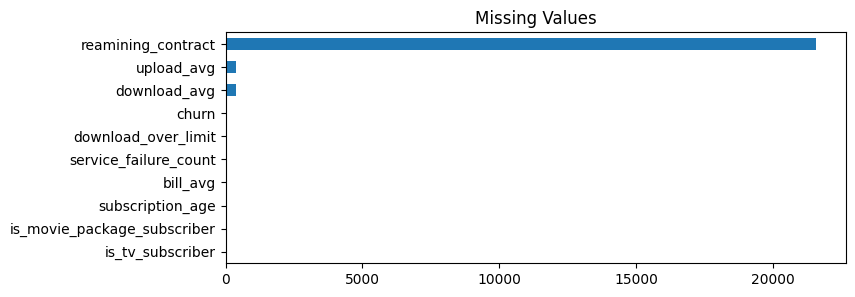

In [65]:
import matplotlib.pyplot as plt
from scipy import stats# Plot
plt.figure(figsize=(8,3))
data.isnull().sum().sort_values(ascending=True).plot(kind='barh')
plt.title("Missing Values")
plt.show()

In [66]:
data["download_over_limit"].unique()

array([0, 3, 7, 2, 5, 1, 6, 4])

In [67]:
data=data.rename(columns={"reamining_contract": "remaining_contract"})

In [68]:
data.groupby(
    data["remaining_contract"].isna()
)["churn"].agg(["count", "mean"])

,count,mean
remaining_contract,,
False,50702,0.400990
True,21572,0.914102


In [69]:
data["remaining_contract"].unique()

array([0.14,  nan, 0.  , 1.38, 1.28, 0.28, 1.8 , 0.01, 0.21, 1.83, 1.82,
       1.85, 1.56, 0.45, 0.44, 1.21, 0.52, 1.1 , 1.2 , 1.66, 0.97, 0.4 ,
       0.46, 0.04, 1.26, 1.74, 1.68, 1.77, 0.12, 1.65, 1.32, 0.33, 1.01,
       1.06, 1.88, 0.99, 1.79, 1.78, 1.93, 1.16, 0.57, 1.95, 1.86, 0.23,
       0.37, 1.96, 0.07, 1.44, 0.15, 0.49, 0.53, 1.27, 1.3 , 1.13, 1.17,
       0.54, 0.1 , 1.43, 1.15, 1.61, 0.27, 0.83, 0.43, 1.02, 0.76, 0.09,
       0.5 , 1.64, 1.  , 0.7 , 1.22, 0.05, 0.65, 0.11, 0.13, 1.62, 1.42,
       0.02, 1.14, 1.34, 1.76, 0.71, 0.17, 1.84, 1.41, 0.24, 0.08, 1.07,
       1.03, 1.5 , 1.89, 1.08, 1.23, 0.29, 0.3 , 0.79, 0.16, 1.12, 0.06,
       1.63, 1.18, 1.67, 0.39, 0.87, 1.05, 1.91, 1.75, 0.25, 1.55, 1.19,
       1.35, 1.53, 0.92, 1.09, 1.58, 0.31, 1.94, 0.93, 0.47, 1.9 , 1.51,
       0.36, 1.59, 0.91, 0.58, 1.97, 1.57, 1.45, 0.18, 0.77, 1.71, 0.82,
       0.78, 1.04, 0.19, 0.88, 0.9 , 1.49, 1.69, 0.38, 1.31, 0.85, 0.22,
       0.55, 0.42, 0.41, 1.11, 1.24, 1.4 , 1.73, 1.

In [70]:
print(f"number of duplicate values: {data.duplicated().sum()/len(data)*100:.2f}%")

number of duplicate values: 2.97%


In [71]:
duplicates = data[data.duplicated()]

print(duplicates)

       is_tv_subscriber  is_movie_package_subscriber  subscription_age  \
37                    0                            0              5.62   
39                    0                            0              5.62   
43                    0                            0              5.62   
59                    0                            0              5.62   
63                    0                            0             11.93   
...                 ...                          ...               ...   
71998                 1                            1              0.61   
72071                 1                            0              0.00   
72134                 0                            0              0.00   
72263                 1                            0              0.02   
72264                 0                            0              0.01   

       bill_avg  remaining_contract  service_failure_count  download_avg  \
37            0                 NaN

In [72]:
data.drop_duplicates(keep='first', inplace=True)

In [73]:
median_contract = data["remaining_contract"].median()

data["missing_remaining_contract"] = data["remaining_contract"].isna().astype(int)
data["remaining_contract"] = data["remaining_contract"].fillna(median_contract)


In [74]:
data["download_avg"]= data["download_avg"].fillna(data["download_avg"].median())
data["upload_avg"]= data["upload_avg"].fillna(data["upload_avg"].median())

In [ ]:
  positive_continuous_cols= [,
       'subscription_age', 'bill_avg', 'remaining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit']

def data_cleaning(data):
    data= data.drop(["id"], axis=1)
    data.drop_duplicates(keep='first', inplace=True)
    data=data.rename(columns={"reamining_contract": "remaining_contract"})
    #filling missing values with median
    # negetive values with 0
    data["missing_remaining_contract"]= data["remaining_contract"].isna().astype(int)
    for col in positive_cols:
        data[col]= data[col].fillna(data[col].median())
        data.loc[data[col]<0, col]= 0
    return data

## correlation

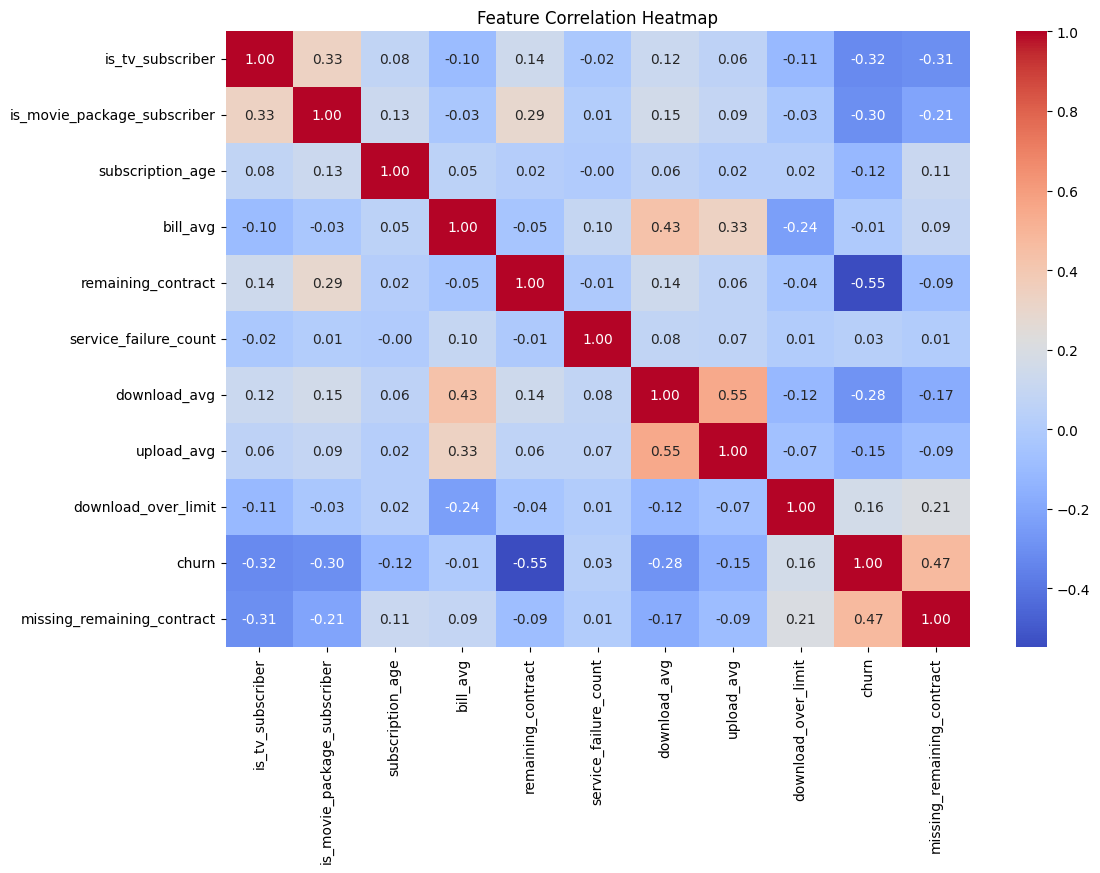

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

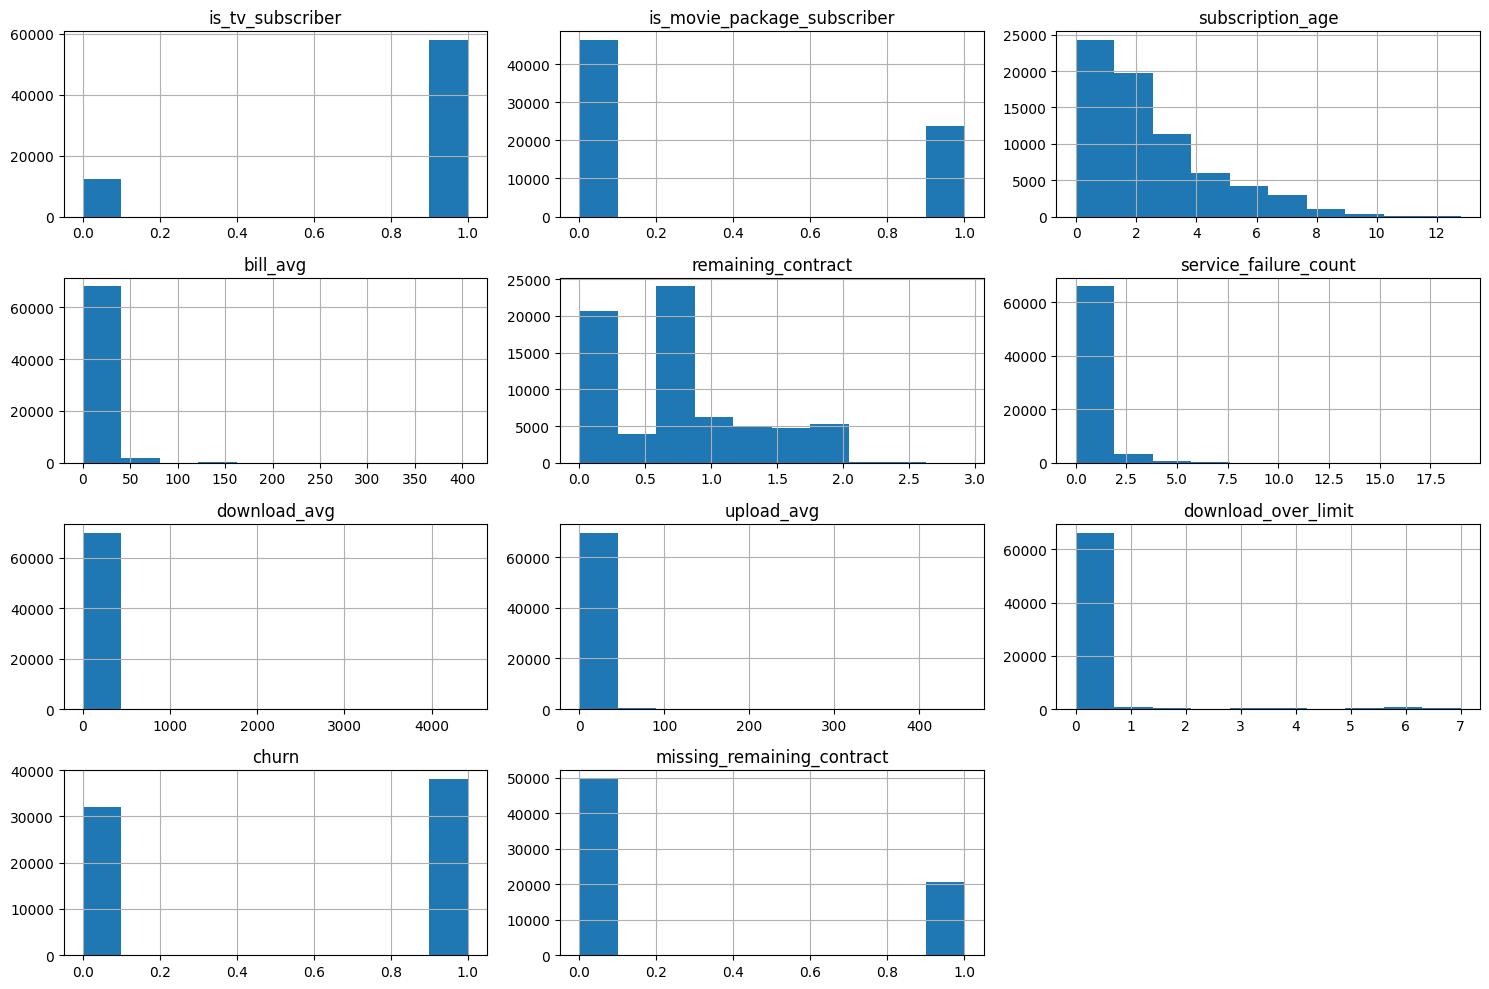

In [76]:
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

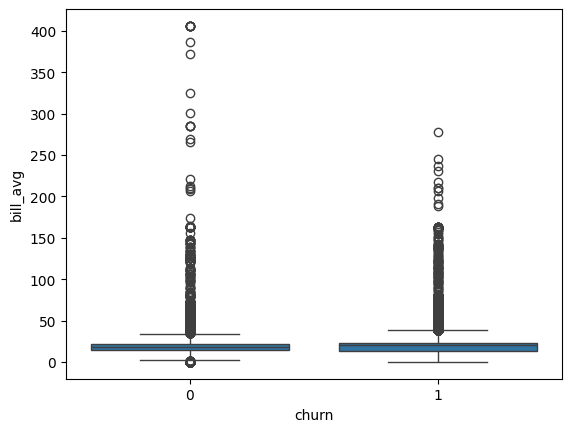

In [77]:
sns.boxplot(
    data=data,
    x="churn",
    y="bill_avg"
)

plt.show()

## feature Enginnering

<Axes: >

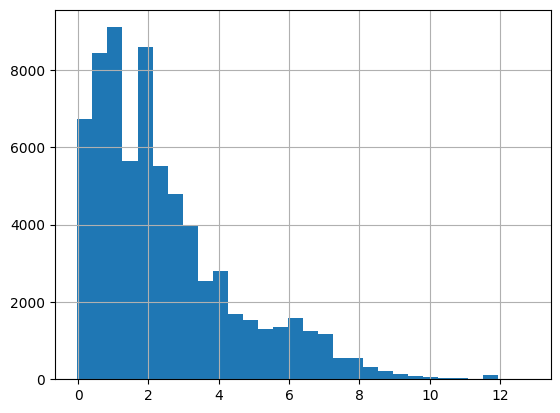

In [79]:
data["subscription_age"].hist(bins=30)


In [80]:
data["num_services_subscribed"]= data[["is_tv_subscriber", "is_movie_package_subscriber"]].sum(axis=1)



In [81]:
import numpy as np
total_usage= data[["download_avg", "upload_avg"]].sum(axis=1)
data["cost_per_usage"]= np.where(
    total_usage>0,
    data["bill_avg"]/total_usage,
    0
    )

In [82]:
print(data["cost_per_usage"].mean())
print(data["cost_per_usage"].std())
print(data["cost_per_usage"].min())
print(data["cost_per_usage"].max())

1.444603865333926
8.668547858253106
0.0
630.0


In [84]:
data.head()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,missing_remaining_contract,num_services_subscribed,cost_per_usage
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,1,2.336449
1,0,0,8.22,0,0.61,0,0.0,0.0,0,1,1,0,0.000000
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,1,1.095890
3,0,0,6.87,21,0.61,1,0.0,0.0,0,1,1,0,0.000000
4,0,0,6.39,0,0.61,0,0.0,0.0,0,1,1,0,0.000000


In [85]:
data.columns

Index(['is_tv_subscriber', 'is_movie_package_subscriber', 'subscription_age',
       'bill_avg', 'remaining_contract', 'service_failure_count',
       'download_avg', 'upload_avg', 'download_over_limit', 'churn',
       'missing_remaining_contract', 'num_services_subscribed',
       'cost_per_usage'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



scaler= StandardScaler()
Numeric_cols= ['subscription_age','bill_avg', 'remaining_contract','service_failure_count','download_avg', 'upload_avg', 'download_over_limit','cost_per_usage','num_services_subscribed']
Binary_cols= ['is_tv_subscriber', 'is_movie_package_subscriber']
Target_col="churn"
X= data[Numeric_cols+Binary_cols]
Y= data[Target_col]
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123,)

X_train[Numeric_cols]=np.log1p(X_train[Numeric_cols])
X_test[Numeric_cols]=np.log1p(X_test[Numeric_cols])



X_train[Numeric_cols]= scaler.fit_transform(X_train[Numeric_cols])
X_test[Numeric_cols]= scaler.transform(X_test[Numeric_cols])

clf= LogisticRegression(penalty="l2", random_state=23, solver="liblinear").fit(X_train, Y_train)
print(clf.score(X_train,Y_train))







0.8236541889483066


/Users/mohaiminulislam/Desktop/ISP Customer_churn mlops/Internet Service Provider Customer Churn/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mohaiminulislam/Desktop/ISP Customer_churn mlops/Internet Service Provider Customer Churn/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mohaiminulislam/Desktop/ISP Customer_churn mlops/Internet Service Provider Customer Churn/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [106]:
X_train

,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,cost_per_usage,num_services_subscribed,is_tv_subscriber,is_movie_package_subscriber
50203,0.062218,-0.102187,1.693763,-0.414898,0.633031,0.323963,-0.227055,-0.454561,-0.043991,1,0
38706,0.695966,0.366937,-0.256586,-0.414898,0.451801,0.186516,-0.227055,-0.153228,1.040151,1,1
63045,-0.896821,0.421386,0.898931,-0.414898,0.507927,0.469620,-0.227055,-0.186002,-0.043991,1,0
45097,0.399749,-0.023135,0.938966,-0.414898,0.335820,0.768565,-0.227055,-0.274410,1.040151,1,1
39830,-1.409370,-1.721198,-1.360042,-0.414898,-0.643315,-0.632872,-0.227055,-0.254077,-0.043991,1,0
...,...,...,...,...,...,...,...,...,...,...,...
34920,-0.726820,0.121137,0.028576,-0.414898,0.124687,-0.232479,-0.227055,0.039473,-0.043991,1,0
45617,0.228366,-1.447871,-1.360042,-0.414898,0.469002,0.063215,-0.227055,-0.680333,1.040151,1,1
32645,0.529540,0.900156,0.028576,-0.414898,0.352663,0.961605,-0.227055,0.174353,-1.897345,0,0
52178,-0.051574,1.003730,-1.162761,-0.414898,0.547380,0.836611,-0.227055,0.057293,-0.043991,1,0


In [ ]:


class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, config: dict=config):
        logger.info("Initializing LogTransformer")
        self.config = config

    def scale_numeric_col(self,df: pd.DataFrame) -> pd.DataFrame:
        numeric_cols = self.config["numeric_cols"]
        for col in numeric_cols:
            df[col] = np.log1p(df[col])
        return df
       
    def fit(self, X, y=None):
        self.scaler.fit(X[self.numeric_cols])
        return self
    
    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        try:
            return self.scale_numeric_col(X)
        except Exception as e:
            logger.warning(f"Error in scaling numeric columns: {e}")
            raise
        

class Mode_trainer:
    def __init__(self, df: pd.DataFrame, config: dict):
        self.df = df
        self.config = config
        
    def split_data(self):
        X = self.df.drop(columns=[self.config["target_col"]])
        y = self.df[self.config["target_col"]]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.config["test_size"], random_state=self.config["random_state"], stratify=y
        )
        return X_train, X_test, y_train, y_test
    
    def get_preprocessor(self):
        numerical_transformer = Pipeline(steps=[
            ('log_transformer', LogTransformer()),
            ('scaler', StandardScaler())
        ])
        
    
        preprocessor = ColumnTransformer(
            transformers=[
                ('numerical', numerical_transformer, self.config["numeric_cols"]),
                ('bin', 'passthrough', self.config["binary_cols"])
            ]
        )
        
        logger.info("Preprocessor created successfully")
        return preprocessor
        
    
    def get_model(self):
        preprocessor = self.get_preprocessor()
        X_train, X_test, y_train, y_test = self.split_data() 
        X_train= preprocessor.fit_transform(X_train)
        X_test = preprocessor.transform(X_test)
        
        for model in self.config["model"]:
            model_name = list(model.keys())
            if model_name == "random_forest":
                model_params = model[model_name]
                model = RandomForestClassifier(random_state=self.config["random_state"], **model_params)
                clf=GridSearchCV(model, param_grid, cv=self.config["cv_folds"], scoring="f1")
                clf.fit(X_train, y_train)
            elif model_name == "xgboost":
                model = XGBClassifier(random_state=self.config["random_state"], **model_params)
                clf=GridSearchCV(model, param_grid, cv=self.config["cv_folds"], scoring="f1")
                clf.fit(X_train, y_train)
            elif model_name == "logistic_regression":
                model = LogisticRegression(solver="liblinear", random_state=self.config["random_state"], **model_params)
                clf=GridSearchCV(model, param_grid, cv=self.config["cv_folds"], scoring="f1")
                clf.fit(X_train, y_train)
                
                
            
        
        

        
        logger.info(f"Model {self.config['model']} created successfully")
        return model
    

In [104]:
print(data.isna().sum().sum())
print(data.describe())

0
       is_tv_subscriber  is_movie_package_subscriber  subscription_age  \
count      70125.000000                 70125.000000      70125.000000   
mean           0.824613                     0.340321          2.485526   
std            0.380300                     0.473820          2.043719   
min            0.000000                     0.000000         -0.020000   
25%            1.000000                     0.000000          0.950000   
50%            1.000000                     0.000000          1.980000   
75%            1.000000                     1.000000          3.370000   
max            1.000000                     1.000000         12.800000   

           bill_avg  remaining_contract  service_failure_count  download_avg  \
count  70125.000000        70125.000000           70125.000000  70125.000000   
mean      19.237447            0.690364               0.282039     44.867760   
std       13.191721            0.586022               0.827224     63.778716   
min        

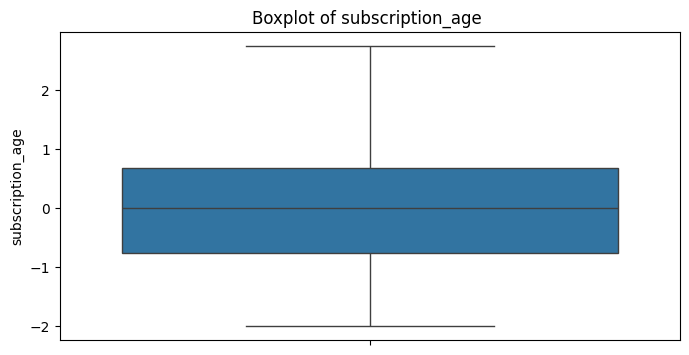

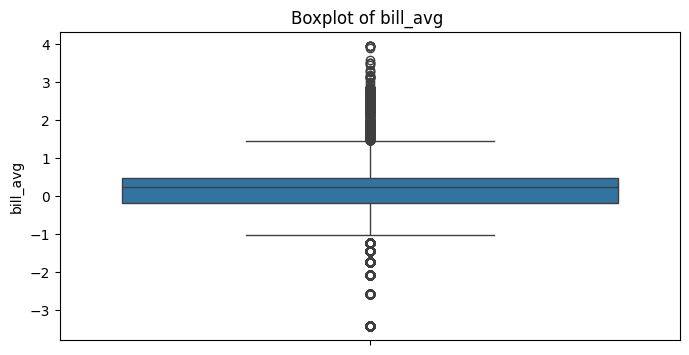

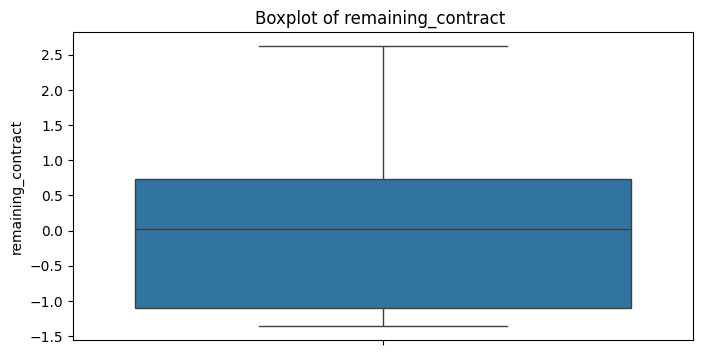

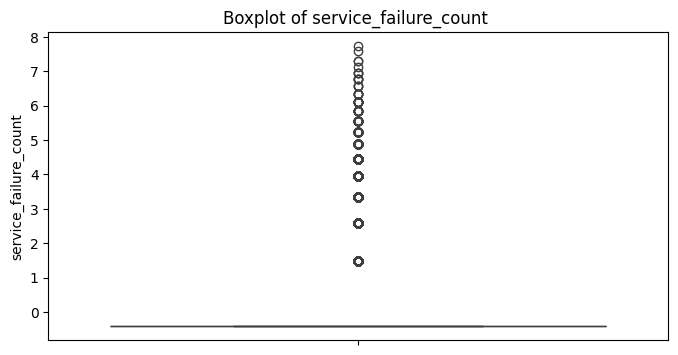

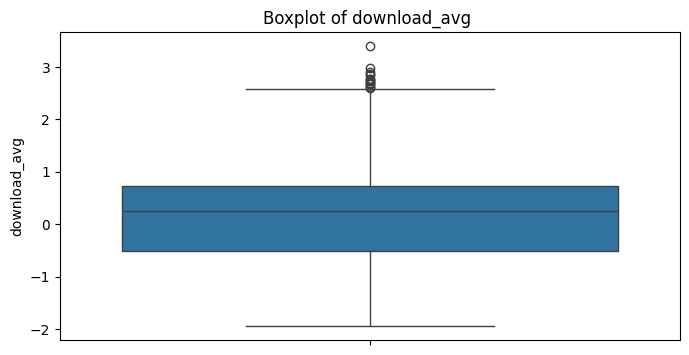

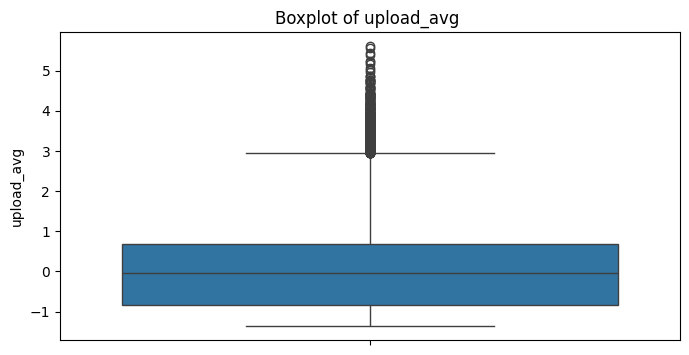

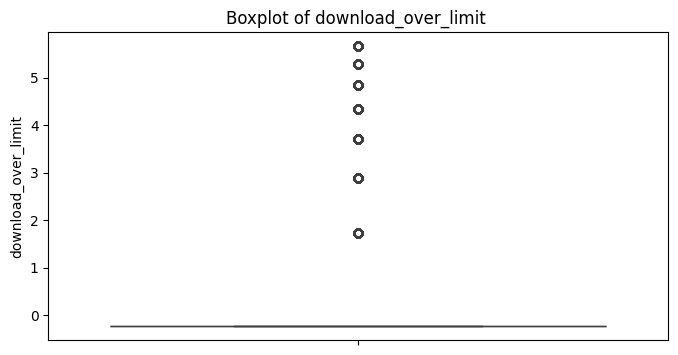

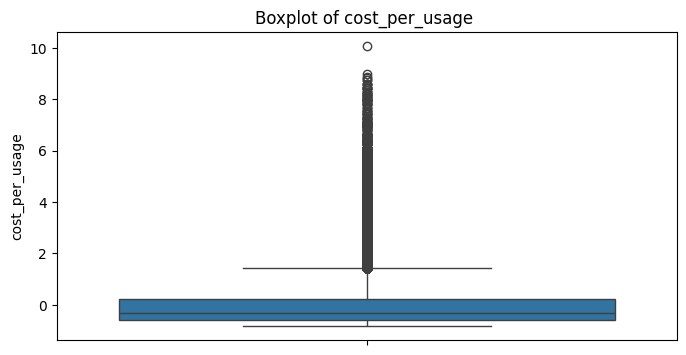

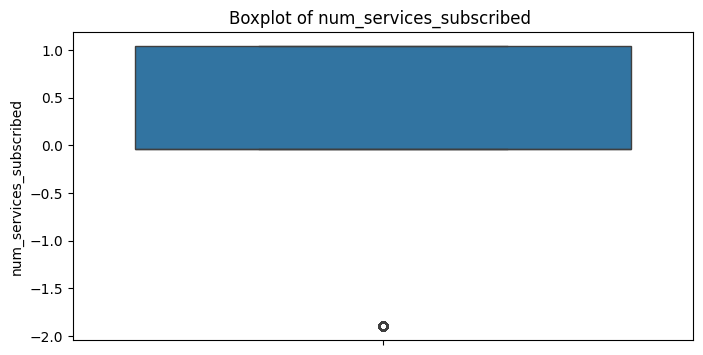

In [100]:
for col in Numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        y=X_train[col]
    )
    plt.title(f"Boxplot of {col} ")
    plt.show()